# CNN for image classification

Use PyTorch to build and train a multilayer CNN to perform image classification on the CIFAR10 dataset

In [1]:
# Settings to mount drive into Google Colab
from google.colab import drive
drive.mount('/content/drive')
ROOT = '/content/drive/MyDrive/Colab Notebooks/Unit3_CNNClassifier_Files'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Settings to run from local machine
import os
ROOT = os.getcwd() + '/Unit3_CNNClassifier_Files'
print(ROOT)

C:\Users\Wes\OneDrive - University of Leeds\OCOM5203M Deep Learning\OCOM5203M_DeepLearning/Unit3_CNNClassifier_Files


In [9]:
import numpy as np
import torch
import torchvision
from torch import nn, optim
from torchvision import transforms, datasets
import matplotlib.pyplot as plt

Access the dataset and produce iterable data loaders of minibatches. Give names to the classes.
Randomly transform the data, producing unique images in each mini-batch.

In [44]:
n_workers = 4
train_batch_size = 512
test_batch_size = 2*train_batch_size

trnsfrm = transforms.Compose([
    transforms.ToTensor(),
    transforms.ColorJitter(hue=0.2, saturation=0.2, brightness=0.2),              # Randomly vary the hue, saturation, and brightness by plus/minus 20%
    transforms.RandomAffine(degrees=10, translate=(0.1,0.1), scale=(0.9,1.1)),    # Randomly rotate, translate, and scale by +/-
    transforms.RandomHorizontalFlip(p=0.5)                                        # Have only done horizontal flip as a vertical flip is unlikely to occur in real life
])

# Load the datasets
train_set = torchvision.datasets.CIFAR10(
    root=ROOT+'./data',
    train=True,
    download=True,
    transform=trnsfrm
)

test_set = torchvision.datasets.CIFAR10(
    root=ROOT+'./data',
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=train_batch_size,
    shuffle=True,
    num_workers=n_workers
)

test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=test_batch_size, # Forward pass only so batch size can be larger
    shuffle=False,
    num_workers=n_workers
)

classes = ("plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck")

Files already downloaded and verified
Files already downloaded and verified


In [11]:
# Checking for GPU availability
if torch.cuda.is_available():
  device_name = torch.device('cuda')
else:
  device_name = torch.device('cpu')

print(f'Device being used: {device_name}')

Device being used: cuda


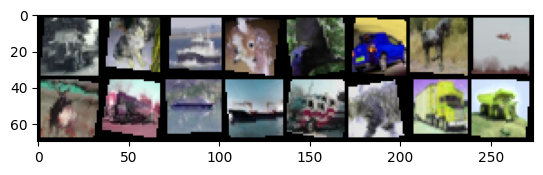

labels ['truck', 'dog', 'ship', 'deer', 'bird', 'car', 'horse', 'plane', 'deer', 'truck']


In [12]:
def timshow(x):
    xa = np.transpose(x.numpy(),(1,2,0))
    plt.imshow(xa)
    plt.show()

# get some random training images using the data loader
dataiter = iter(train_loader)
images, labels = next(dataiter)
#images, labels = images.to(device_name), labels.to(device_name)

# show images and labels
timshow(torchvision.utils.make_grid(images))

print(f"labels {[classes[labels[i]] for i in range(10)]}")


Computation of loss and accuracy for given dataset loader and model. This will be used for computing loss and accuracy on the test set after each training epoch.

In [13]:
def stats(loader, net):
    correct = 0
    total = 0
    running_loss = 0
    n = 0    # counter for number of minibatches
    with torch.no_grad():                                      # We don't need to calculate the gradient for the testing
        for data in loader:
            images, labels = data
            images, labels = images.to(device_name), labels.to(device_name)
            outputs = net(images)

            # accumulate loss
            running_loss += loss_fn(outputs, labels)            # Add mini-batch loss to overall epoch loss
            n += 1

            # accumulate data for accuracy
            _, predicted = torch.max(outputs.data, 1)           # Find the prediction with the greatest confidence / score
            total += labels.size(0)                             # add in the number of labels in this minibatch
            correct += (predicted == labels).sum().item()       # count the number of times the predicted labels were correct

    return running_loss/n, correct/total                        # return the average epoch loss and the percentage of correct predictions

## Define model

In [14]:
net = nn.Sequential(                                           # defining a sequential model
    nn.Conv2d(in_channels=3,out_channels=8, kernel_size=5),    # no padding, stride=1, dilation=1 by default; 3 input channels for RGB but 8 output channels, so we need 3*8 5x5 kernels and 8 bias values
    nn.ReLU(),                                                 # applying a ReLU to the output of the convolutions
    nn.MaxPool2d(kernel_size=2, stride=2),                     # standard max-pooling layer
    nn.Conv2d(in_channels=8,out_channels=16, kernel_size=5),   # typically double-up the size of the number of outputs whenever we halve the inputs (due to max-pool?)
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16*5*5,64),                                      # FCL with 16*5*5 (16 kernels of 5*5 size) inputs and 64 output nodes
    nn.ReLU(),
    nn.Linear(64,10)                                           # FCL with 64 inputs and the 10 output classifications
)

if torch.cuda.is_available():
  net.cuda()

for param in net.parameters():
    print(param.shape)


torch.Size([8, 3, 5, 5])
torch.Size([8])
torch.Size([16, 8, 5, 5])
torch.Size([16])
torch.Size([64, 400])
torch.Size([64])
torch.Size([10, 64])
torch.Size([10])


## Train model

In [45]:
%%time

nepochs = 5
statsrec = np.zeros((4,nepochs))

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

for epoch in range(nepochs):  # loop over the dataset multiple times
    correct = 0          # number of examples predicted correctly (for accuracy)
    total = 0            # number of examples
    running_loss = 0.0   # accumulated loss (for mean loss)
    n = 0                # number of minibatches
    for data in train_loader:
        inputs, labels = data
        inputs, labels = inputs.to(device_name), labels.to(device_name)

         # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward, backward, and update parameters
        outputs = net(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        # accumulate loss
        running_loss += loss.item()
        n += 1

        # accumulate data for accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)    # add in the number of labels in this minibatch
        correct += (predicted == labels).sum().item()  # add in the number of correct labels

    # collect together statistics for this epoch
    ltrn = running_loss/n
    atrn = correct/total
    ltst, atst = stats(test_loader, net)
    '''
    print(type(ltrn))
    print(type(atrn))
    print(type(ltst))
    print(type(atst))
    '''
    statsrec[:,epoch] = (ltrn, atrn, ltst.cpu(), atst)
    print(f"epoch: {epoch} training loss: {ltrn: .3f} training accuracy: {atrn: .1%}  test loss: {ltst: .3f} test accuracy: {atst: .1%}")



epoch: 0 training loss:  1.098 training accuracy:  61.6%  test loss:  0.971 test accuracy:  66.5%
epoch: 1 training loss:  1.098 training accuracy:  61.7%  test loss:  0.973 test accuracy:  66.7%
epoch: 2 training loss:  1.099 training accuracy:  61.3%  test loss:  0.973 test accuracy:  66.5%
epoch: 3 training loss:  1.098 training accuracy:  61.7%  test loss:  0.972 test accuracy:  66.6%
epoch: 4 training loss:  1.090 training accuracy:  61.7%  test loss:  0.971 test accuracy:  66.7%
CPU times: total: 40.9 s
Wall time: 2min 19s


Plot loss and accuracy on training and test sets

In [18]:
results_path = ROOT+'/cnnclassifier200epochs.pt'

# save network parameters, losses and accuracy
torch.save({"state_dict": net.state_dict(), "stats": statsrec}, results_path)

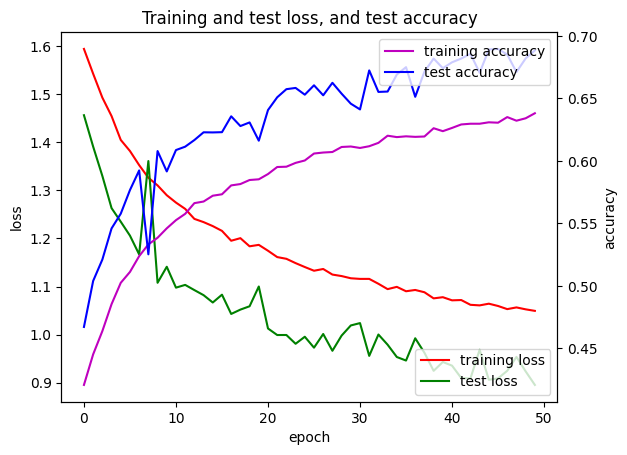

In [20]:
results_path = ROOT+'/cnnclassifier200epochs.pt'
data = torch.load(results_path)
statsrec = data["stats"]
fig, ax1 = plt.subplots()
plt.plot(statsrec[0], 'r', label = 'training loss', )
plt.plot(statsrec[2], 'g', label = 'test loss' )
plt.legend(loc='lower right')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training and test loss, and test accuracy')
ax2=ax1.twinx()
ax2.plot(statsrec[1], 'm', label = 'training accuracy')
ax2.plot(statsrec[3], 'b', label = 'test accuracy')
ax2.set_ylabel('accuracy')
plt.legend(loc='upper right')
fig.savefig("roc.svg")
plt.show()